**WEEK 3: DAY 1**

Welcome to **Google Colab** - using free and powerful compute in the cloud.

**Google Colab** gives you a **remote Notebook-style browser window** on to a machine, and you run code "locally" on that machine.

**Benefits of Colab**
1. Free access to **T4 GPUs**.
2. Easy ability to share code and collaborate on it.
3. Everyone gets to use identical code -- no environment differences.

**Downsides of Colab**

1. As it's free, Google reserves the right to bump you off the box at any point ("reset the runtime"), and this happens most quickly if no code is running.
2. They can also downgrade you from a T4 to a CPU-only box. Sometimes this happens silently. You need to start everything again from the top. Paid plans last longer.
3. You need to pip install packages every single time.
4. There's some latency - it's not as interactive as coding on your own box.

**Survival Guide**


1. Always start by pressing the drop down arrow by Connect on the top right, and "Connect to a hosted runtime: T4".
2. From that dropdown, "View Resources" to check you have a GPU and monitor memory.
3. If things go awry, Runtime >> Disconnect and Delete Runtime, Connect again, and then run cells from the top.
4. Always run the pip installs! Ignore pip dependency errors.
5. Runtime >> Restart session: this restarts the Python Kernel, but pip packages remain installed and the disk remains the same.
6.Runtime >> Disconnect and delete session. This wipes everything.

**transformers**==4.56.2: Installs version 4.56.2 of Hugging Face's Transformers library. This is the industry-standard library used to download, run, and fine-tune large models like BERT, GPT, Llama, and various Text-to-Speech/Speech-to-Text models.

**diffusers**==0.32.2: Installs version 0.32.2 of Hugging Face's Diffusers library. This library is specifically built for image and audio generation diffusion models (like Stable Diffusion or FLUX).

In [3]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128


In [4]:
!pip install --upgrade transformers diffusers datasets gradio python-dotenv huggingface_hub ipython accelerate

In [5]:
import torch

print("--- GPU Verification ---")
print("Is CUDA available?:   ", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Active GPU Device:   ", torch.cuda.get_device_name(0))
    print("VRAM Available (GB): ", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
else:
    print("❌ PyTorch still cannot see your GPU. We may need to re-verify the environment pathway.")

--- GPU Verification ---
Is CUDA available?:    True
Active GPU Device:    NVIDIA GeForce RTX 5060 Laptop GPU
VRAM Available (GB):  7.96


[ERROR] `loss` is part of GlmImageCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in d:\ujjwal\engineering_llm\.venv\Lib\site-packages\transformers\models\glm_image\modeling_glm_image.py.
[ERROR] `logits` is part of GlmImageCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in d:\ujjwal\engineering_llm\.venv\Lib\site-packages\transformers\models\glm_image\modeling_glm_image.py.
[ERROR] `loss` is part of Qwen3VLCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in d:\ujjwal\engineering_llm\.venv\Lib\site-packages\transformers\models\qwen3_vl\modeling_qwen3_vl.py.
[ERROR] `logits` is part of Qwen3VLCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in d:\ujjwal\engineering_llm\.venv\Lib\site-packages\transformers\models\q

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
d:\ujjwal\engineering_llm\.venv\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

d:\ujjwal\engineering_llm\.venv\Lib\site-packages\diffusers\pipelines\stable_diffusion_xl\pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


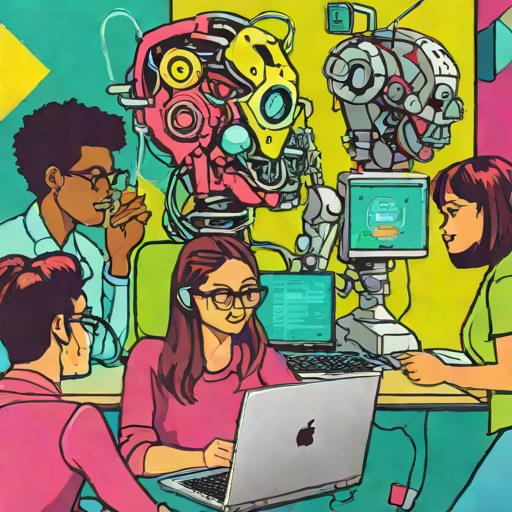

In [6]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from IPython.display import display
from diffusers import AutoPipelineForText2Image
import torch

# 1. Handle Authentication
load_dotenv(override=True)
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    login(hf_token, add_to_git_credential=True)

# 2. Load the Pipeline directly to GPU
pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo", 
    torch_dtype=torch.float16, 
    variant="fp16"
)
pipe.to('cuda')

# 3. Generate the Image
prompt = "A class of students learning AI engineering in a vibrant pop-art style"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]

# 4. Display
display(image)

In [ ]:
# Restart the kernel

import IPython
IPython.Application.instance().kernel.do_shutdown(True)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

d:\ujjwal\engineering_llm\.venv\Lib\site-packages\diffusers\pipelines\stable_diffusion_xl\pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


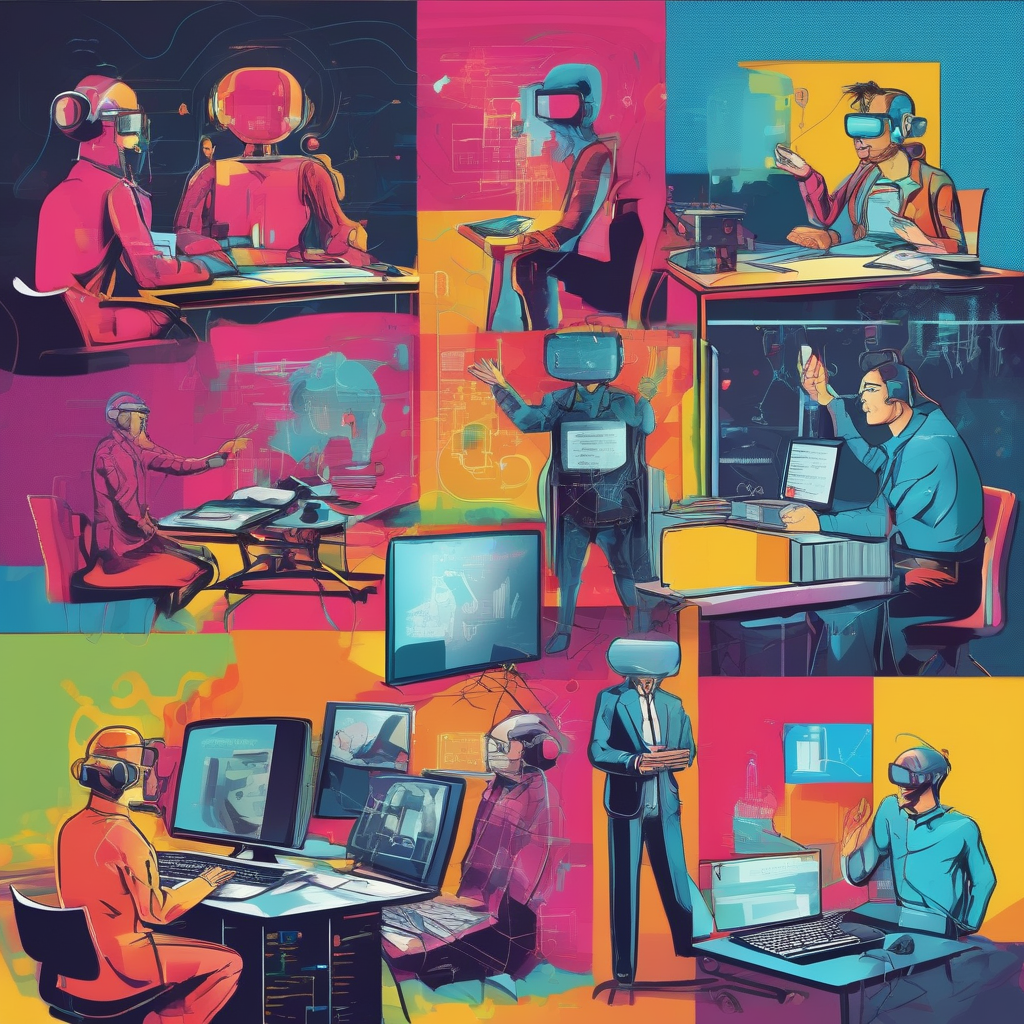

In [1]:
from IPython.display import display
from diffusers import DiffusionPipeline
import torch

pipe = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, use_safetensors=True, variant="fp16")
pipe.to("cuda")

prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style"

image = pipe(prompt=prompt, num_inference_steps=30).images[0]

display(image)


In [ ]:
# Restart the kernel

import IPython
IPython.Application.instance().kernel.do_shutdown(True)

In [1]:
from diffusers import DiffusionPipeline
import torch

base = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, variant="fp16", use_safetensors=True)
base.to("cuda")
refiner = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-refiner-1.0", text_encoder_2=base.text_encoder_2, vae=base.vae, torch_dtype=torch.float16, use_safetensors=True, variant="fp16",)
refiner.to("cuda")

# Define how many steps and what % of steps to be run on each experts (80/20) here
n_steps = 40
high_noise_frac = 0.8

prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style"

# run both experts
image = base(
    prompt=prompt,
    num_inference_steps=n_steps,
    denoising_end=high_noise_frac,
    output_type="latent",
).images

image = refiner(
    prompt=prompt,
    num_inference_steps=n_steps,
    denoising_start=high_noise_frac,
    image=image,
).images[0]

display(image)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

d:\ujjwal\engineering_llm\.venv\Lib\site-packages\diffusers\pipelines\stable_diffusion_xl\pipeline_stable_diffusion_xl_img2img.py:896: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


OutOfMemoryError: CUDA out of memory. Tried to allocate 1024.00 MiB. GPU 0 has a total capacity of 7.96 GiB of which 0 bytes is free. Of the allocated memory 12.75 GiB is allocated by PyTorch, and 506.37 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

In [1]:
from transformers import pipeline
from datasets import load_dataset
import soundfile as sf
import torch
from IPython.display import Audio

synthesiser = pipeline("text-to-speech", "microsoft/speecht5_tts", device='cuda')
embeddings_dataset = load_dataset("matthijs/cmu-arctic-xvectors", split="validation", trust_remote_code=True)
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)
speech = synthesiser("Hi to an artificial intelligence engineer, on the way to mastery!", forward_params={"speaker_embeddings": speaker_embedding})

Audio(speech["audio"], rate=speech["sampling_rate"])

: 

In [ ]:
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

In [7]:
import torch

print("--- GPU Verification ---")
print("Is CUDA available?:   ", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Active GPU Device:   ", torch.cuda.get_device_name(0))
    print("VRAM Available (GB): ", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
else:
    print("❌ PyTorch still cannot see your GPU. We may need to re-verify the environment pathway.")

--- GPU Verification ---
Is CUDA available?:    True
Active GPU Device:    NVIDIA GeForce RTX 5060 Laptop GPU
VRAM Available (GB):  7.96


In [1]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.11.0+cu128
CUDA available: True


In [3]:
!pip install soundfile

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   -------------------- ------------------- 0.5/1.0 MB 1.4 MB/s eta 0:00:01
   ------------------------------ --------- 0.8/1.0 MB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 1.3 MB/s  0:00:00


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import soundfile as sf
from dotenv import load_dotenv
from huggingface_hub import login
from IPython.display import display, Audio
from datasets import load_dataset
print("Step 1: Basic libraries loaded successfully!")

# Let's test Torch by itself
import torch
print(f"Step 2: Torch loaded successfully! CUDA available: {torch.cuda.is_available()}")

# Let's test Transformers
from transformers import pipeline
print("Step 3: Transformers loaded successfully!")

# Let's test Diffusers
from diffusers import AutoPipelineForText2Image, DiffusionPipeline
print("Step 4: Diffusers loaded successfully!")

Step 1: Basic libraries loaded successfully!
Step 2: Torch loaded successfully! CUDA available: True
Step 3: Transformers loaded successfully!


[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


[ERROR] `loss` is part of GlmImageCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in d:\ujjwal\engineering_llm\.venv\Lib\site-packages\transformers\models\glm_image\modeling_glm_image.py.
[ERROR] `logits` is part of GlmImageCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in d:\ujjwal\engineering_llm\.venv\Lib\site-packages\transformers\models\glm_image\modeling_glm_image.py.
[ERROR] `loss` is part of Qwen3VLCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in d:\ujjwal\engineering_llm\.venv\Lib\site-packages\transformers\models\qwen3_vl\modeling_qwen3_vl.py.
[ERROR] `logits` is part of Qwen3VLCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in d:\ujjwal\engineering_llm\.venv\Lib\site-packages\transformers\models\q

In [1]:
import os
# Prevent OpenMP and memory allocation crashes on Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import soundfile as sf
from transformers import pipeline
from datasets import load_dataset
from IPython.display import Audio

# 1. Clear out any residual VRAM before initializing
torch.cuda.empty_cache()

# 2. Initialize the pipeline with half-precision (float16) compression
# Pass `torch_dtype=torch.float16` to compress the model weights in VRAM
synthesiser = pipeline(
    "text-to-speech", 
    "microsoft/speecht5_tts", 
    torch_dtype=torch.float16,
    device_map="auto" # <-- The moment your VRAM is completely full, it automatically pushes the remaining layers of the model into your system RAM (CPU).
)

# 3. Load dataset and format speaker embeddings to match the float16 precision
embeddings_dataset = load_dataset("matthijs/cmu-arctic-xvectors", split="validation", trust_remote_code=True)

# CRITICAL: The speaker embedding tensor must be converted to .half() (float16) 
# to match the compressed pipeline, otherwise PyTorch will throw a type-mismatch error.
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0).cuda().half()

# 4. Generate speech safely
speech = synthesiser(
    "Hi to an artificial intelligence engineer, on the way to mastery!", 
    forward_params={"speaker_embeddings": speaker_embedding}
)

# 5. Play audio output
Audio(speech["audio"], rate=speech["sampling_rate"])

: 

In [3]:
import os
# Force sequential CUDA allocation and prevent OpenMP crashes
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
from diffusers import DiffusionPipeline

# 1. Clear out any junk left over in your GPU memory
torch.cuda.empty_cache()

# 2. When you load your pipeline (example using Stable Diffusion), 
# always use float16 and offload to CPU if your GPU has less than 12GB VRAM.
model_id = "runwayml/stable-diffusion-v1-5" 

pipe = DiffusionPipeline.from_pretrained(
    model_id, 
    torch_dtype=torch.float16, # Uses half the memory of default float32
    use_safetensors=True
)

# Move to GPU safely
pipe = pipe.to("cuda")

# CRITICAL FOR WINDOWS/LOW VRAM: 
# If it still crashes here, uncomment the line below to save massive VRAM:
# pipe.enable_model_cpu_offload()

print("Pipeline loaded and ready to generate without crashing!")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

d:\ujjwal\engineering_llm\.venv\Lib\site-packages\torch\nn\modules\module.py:1370: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return t.to(


Pipeline loaded and ready to generate without crashing!


In [2]:
# 1. Handle Authentication
load_dotenv(override=True)
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


#### WORKNIG WITH MORE SOPHISTICATED POWERFULL MODELS, REQUIRING 100 GB CUDA SPACE

In [ ]:
import torch
from diffusers import FluxPipeline
from IPython.display import display
from datetime import datetime

start = datetime.now()

pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-schnell", torch_dtype=torch.bfloat16).to("cuda")
generator = torch.Generator(device="cuda").manual_seed(0)
prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style"

# Generate the image using the GPU
image = pipe(
    prompt,
    guidance_scale=0.0,
    num_inference_steps=4,
    max_sequence_length=256,
    generator=generator
).images[0]

display(image)

stop = datetime.now()

#### USING PIPELINES FROM HUGGING FACE

**Welcome to pipelines**

The HuggingFace transformers library provides APIs at two different levels.

The High Level API for using open-source models for typical inference tasks is called **pipelines**. It's incredibly easy to use.

You create a pipeline using something like:

`my_pipeline = pipeline("the_task_I_want_to_do")`

Followed by

`result = my_pipeline(my_input)`



Before we start, 2 important pro-tips for using Colab:

**Pro-tip 1:**

Data Science code often gives warnings and messages. They can mostly be safely ignored! Glance over them, and if something goes wrong later, perhaps they can give you a clue.

**Pro-tip 2:**

In the middle of running a Colab, you might get an error like this:

Runtime error: CUDA is required but not available for bitsandbytes. Please consider installing [...]

This is a super-misleading error message! Please don't try changing versions of packages...

This actually happens because Google has switched out your Colab runtime, perhaps because Google Colab was too busy. The solution is:

1. Kernel menu >> Disconnect and delete runtime.
2. Reload the colab from fresh and Edit menu >> Clear All Outputs.
3. Connect to a new T4 using the button at the top right.
4. Select "View resources" from the menu on the top right to confirm you have a GPU.
5. Rerun the cells in the colab, from the top down, starting with the pip installs.

**TRAINING VS INFERENCE**

1. TRAINING

**Training** is when you provide a model with data for it to adapt to get better at a task in the future. It does this by updating its internal settings - the parameters or weights of the model. If you're Training a model that's already had some training, the activity is called "fine-tuning".

2. INFERENCE

**Inference** is when you are working with a model that has _already been trained_. You are using that model to produce new outputs on new inputs, taking advantage of everything it learned while it was being trained. Inference is also sometimes referred to as "Execution" or "Running a model".

All of our use of APIs for GPT, Claude and Gemini in the last weeks are examples of **inference**. The "P" in GPT stands for "Pre-trained", meaning that it has already been trained with data (lots of it!) In week 6 we will try fine-tuning GPT ourselves.
  
The pipelines API in HuggingFace is only for use for **inference** - running a model that has already been trained. In week 7 we will be training our own model, and we will need to use the more advanced HuggingFace APIs that we look at in the up-coming lecture.


A simple way to run inference for common tasks, without worrying about all the plumbing, picking reasonable defaults.

**How it works:**

**STEP 1**: Create a pipeline - a function you can then call

```python
my_pipeline = pipeline(task, model=xx, device=xx)
```

If you don't specify a model, then Hugging Face picks one for you that's the default for the task. Specify "cuda" for the device to use an NVIDIA GPU like the one on the T4. Specify "mps" on a Mac.


**STEP 2**: Then call it as many times as you want:

```python
my_pipeline(input1)
my_pipeline(input2)
```